<a href="https://colab.research.google.com/github/Vishnu252005/3js_Multiple_window/blob/main/AI_Driven_Smart_Waste_Segregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7️⃣ AI-Driven Smart Waste Segregation

**Theme:** Environmental Intelligence & IoT

**Module Number:** *(II , III AND V)*

**SDG Goals:** SDG 12 – Responsible Consumption, SDG 15 – Life on Land

**Ethical/WR Aspect:** Impact of automation on low-income waste workers.

**Dataset:** Waste Classification Data (Kaggle)

**Tasks:**
1.  Apply Decision Tree, Naive Bayes, Logistic Regression, and ANN to classify waste types (Organic, Plastic, Metal, E-waste).
2.  Compare Accuracy, F1 Score, and Inference Time.
3.  Visualize decision boundaries or sample predictions.
4.  Discuss ethical trade-offs between automation efficiency and job sustainability.

**NBA Mapping:** PO1, PO2, PO3, PO6, PO7, PO8, PO11
**WKs:** WK2, WK4, WK8

In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vishnus1252005","key":"33f2cdba60ca0c53ac3d747b1397e70e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d techsash/waste-classification-data


Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
waste-classification-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip waste-classification-data.zip


Archive:  waste-classification-data.zip
replace DATASET/TEST/O/O_12568.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

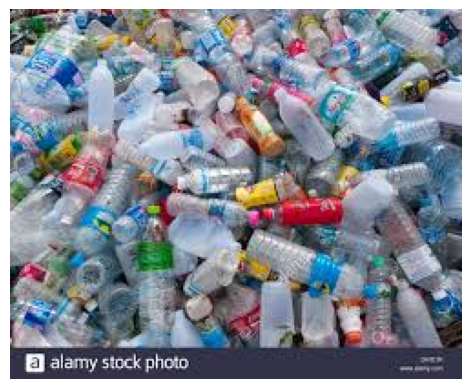

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Example: Show one image
img_path = 'dataset/DATASET/TRAIN/R/R_998.jpg'
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
import os
import random

# Define paths
train_dir = 'dataset/DATASET/TRAIN'
test_dir = 'dataset/DATASET/TEST'

# Create lists for image paths and labels
train_image_paths = []
train_labels = []
test_image_paths = []
test_labels = []

for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            train_image_paths.append(os.path.join(class_dir, img_name))
            train_labels.append(class_name)

for class_name in os.listdir(test_dir):
    class_dir = os.path.join(test_dir, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            test_image_paths.append(os.path.join(class_dir, img_name))
            test_labels.append(class_name)

# --- Modifications to sample a small subset ---
sample_size = 500  # You can adjust this number
train_sample_indices = random.sample(range(len(train_image_paths)), min(sample_size, len(train_image_paths)))
test_sample_indices = random.sample(range(len(test_image_paths)), min(sample_size, len(test_image_paths)))

train_image_paths_subset = [train_image_paths[i] for i in train_sample_indices]
train_labels_subset = [train_labels[i] for i in train_sample_indices]
test_image_paths_subset = [test_image_paths[i] for i in test_sample_indices]
test_labels_subset = [test_labels[i] for i in test_sample_indices]

train_image_paths = train_image_paths_subset
train_labels = train_labels_subset
test_image_paths = test_image_paths_subset
test_labels = test_labels_subset
# --- End of modifications ---


print(f"Number of training images (subset): {len(train_image_paths)}")
print(f"Number of testing images (subset): {len(test_image_paths)}")
print(f"Training labels example (subset): {train_labels[:5]}")
print(f"Testing labels example (subset): {test_labels[:5]}")

Number of training images (subset): 500
Number of testing images (subset): 500
Training labels example (subset): ['R', 'O', 'O', 'R', 'R']
Testing labels example (subset): ['R', 'O', 'O', 'O', 'R']


### Subtask: Preprocess Images and Labels
Resize images to a fixed size (e.g., 128x128 pixels) and encode the labels.

In [ ]:
from PIL import Image
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

img_height, img_width = 128, 128

def preprocess_image(image_path):
    img = Image.open(image_path).resize((img_width, img_height))
    # Convert grayscale images to RGB
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img_array = np.array(img) / 255.0  # Normalize pixel values
    return img_array

# Preprocess training images
train_images = np.array([preprocess_image(img_path) for img_path in train_image_paths])

# Preprocess testing images
test_images = np.array([preprocess_image(img_path) for img_path in test_image_paths])

# Encode labels
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Convert to one-hot encoding
train_labels_one_hot = to_categorical(train_labels_encoded)
test_labels_one_hot = to_categorical(test_labels_encoded)

print(f"Shape of training images: {train_images.shape}")
print(f"Shape of testing images: {test_images.shape}")
print(f"Shape of training labels (encoded): {train_labels_encoded.shape}")
print(f"Shape of testing labels (encoded): {test_labels_encoded.shape}")
print(f"Shape of training labels (one-hot): {train_labels_one_hot.shape}")
print(f"Shape of testing labels (one-hot): {test_labels_one_hot.shape}")
print(f"Classes: {label_encoder.classes_}")

Shape of training images: (500, 128, 128, 3)
Shape of testing images: (500, 128, 128, 3)
Shape of training labels (encoded): (500,)
Shape of testing labels (encoded): (500,)
Shape of training labels (one-hot): (500, 2)
Shape of testing labels (one-hot): (500, 2)
Classes: ['O' 'R']


## Model Implementation and Training

### Subtask: Implement and Train Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import time
from sklearn.metrics import accuracy_score, f1_score

# Flatten the images for Decision Tree
n_samples_train, h, w, c = train_images.shape
train_images_flat = train_images.reshape((n_samples_train, h * w * c))

n_samples_test, h, w, c = test_images.shape
test_images_flat = test_images.reshape((n_samples_test, h * w * c))


# Implement and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

start_time = time.time()
dt_model.fit(train_images_flat, train_labels_encoded)
dt_training_time = time.time() - start_time

# Predict and evaluate
start_time = time.time()
dt_predictions = dt_model.predict(test_images_flat)
dt_inference_time = time.time() - start_time

dt_accuracy = accuracy_score(test_labels_encoded, dt_predictions)
dt_f1 = f1_score(test_labels_encoded, dt_predictions, average='weighted')

print(f"Decision Tree Training Time: {dt_training_time:.4f} seconds")
print(f"Decision Tree Inference Time: {dt_inference_time:.4f} seconds")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree F1 Score: {dt_f1:.4f}")

Decision Tree Training Time: 27.9811 seconds
Decision Tree Inference Time: 0.0799 seconds
Decision Tree Accuracy: 0.7400
Decision Tree F1 Score: 0.7387


### Subtask: Implement and Train Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Implement and train Naive Bayes
nb_model = GaussianNB()

start_time = time.time()
nb_model.fit(train_images_flat, train_labels_encoded)
nb_training_time = time.time() - start_time

# Predict and evaluate
start_time = time.time()
nb_predictions = nb_model.predict(test_images_flat)
nb_inference_time = time.time() - start_time

nb_accuracy = accuracy_score(test_labels_encoded, nb_predictions)
nb_f1 = f1_score(test_labels_encoded, nb_predictions, average='weighted')

print(f"Naive Bayes Training Time: {nb_training_time:.4f} seconds")
print(f"Naive Bayes Inference Time: {nb_inference_time:.4f} seconds")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Naive Bayes F1 Score: {nb_f1:.4f}")

Naive Bayes Training Time: 0.6988 seconds
Naive Bayes Inference Time: 0.6302 seconds
Naive Bayes Accuracy: 0.7480
Naive Bayes F1 Score: 0.7479


### Subtask: Implement and Train Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Implement and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
lr_model.fit(train_images_flat, train_labels_encoded)
lr_training_time = time.time() - start_time

# Predict and evaluate
start_time = time.time()
lr_predictions = lr_model.predict(test_images_flat)
lr_inference_time = time.time() - start_time

lr_accuracy = accuracy_score(test_labels_encoded, lr_predictions)
lr_f1 = f1_score(test_labels_encoded, lr_predictions, average='weighted')

print(f"Logistic Regression Training Time: {lr_training_time:.4f} seconds")
print(f"Logistic Regression Inference Time: {lr_inference_time:.4f} seconds")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression F1 Score: {lr_f1:.4f}")

Logistic Regression Training Time: 6.8661 seconds
Logistic Regression Inference Time: 0.0793 seconds
Logistic Regression Accuracy: 0.8020
Logistic Regression F1 Score: 0.7998


### Subtask: Implement and Train Artificial Neural Network (ANN) Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Implement and train ANN
ann_model = Sequential([
    Flatten(input_shape=(img_height, img_width, 3)),
    Dense(128, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

start_time = time.time()
ann_model.fit(train_images, train_labels_one_hot, epochs=10, batch_size=32, verbose=0)
ann_training_time = time.time() - start_time

# Predict and evaluate
start_time = time.time()
ann_predictions_prob = ann_model.predict(test_images)
ann_predictions = np.argmax(ann_predictions_prob, axis=1)
ann_inference_time = time.time() - start_time

ann_accuracy = accuracy_score(test_labels_encoded, ann_predictions)
ann_f1 = f1_score(test_labels_encoded, ann_predictions, average='weighted')

print(f"ANN Training Time: {ann_training_time:.4f} seconds")
print(f"ANN Inference Time: {ann_inference_time:.4f} seconds")
print(f"ANN Accuracy: {ann_accuracy:.4f}")
print(f"ANN F1 Score: {ann_f1:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
ANN Training Time: 22.3106 seconds
ANN Inference Time: 0.9823 seconds
ANN Accuracy: 0.7140
ANN F1 Score: 0.6854


## Model Evaluation and Visualization

### Subtask: Compare Model Performance
Compare Accuracy, F1 Score, and Inference Time for all models.

In [ ]:
import pandas as pd

# Create a dictionary to store the results
results = {
    'Model': ['Decision Tree', 'Naive Bayes', 'Logistic Regression', 'ANN'],
    'Accuracy': [dt_accuracy, nb_accuracy, lr_accuracy, ann_accuracy],
    'F1 Score': [dt_f1, nb_f1, lr_f1, ann_f1],
    'Inference Time (s)': [dt_inference_time, nb_inference_time, lr_inference_time, ann_inference_time]
}

results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,Accuracy,F1 Score,Inference Time (s)
0,Decision Tree,0.740,0.738739,0.079906
1,Naive Bayes,0.748,0.747879,0.630193
2,Logistic Regression,0.802,0.799785,0.079278
3,ANN,0.714,0.685415,0.982302


### Subtask: Visualize Model Performance
Visualize the comparison of Accuracy, F1 Score, and Inference Time using bar charts.

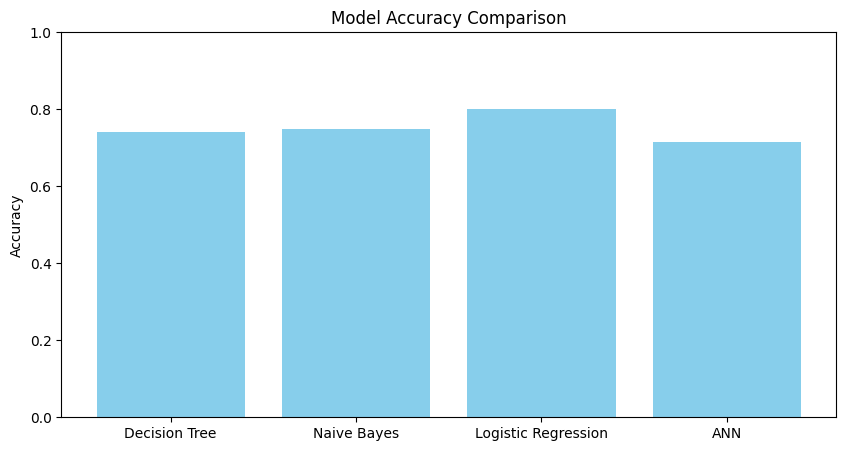

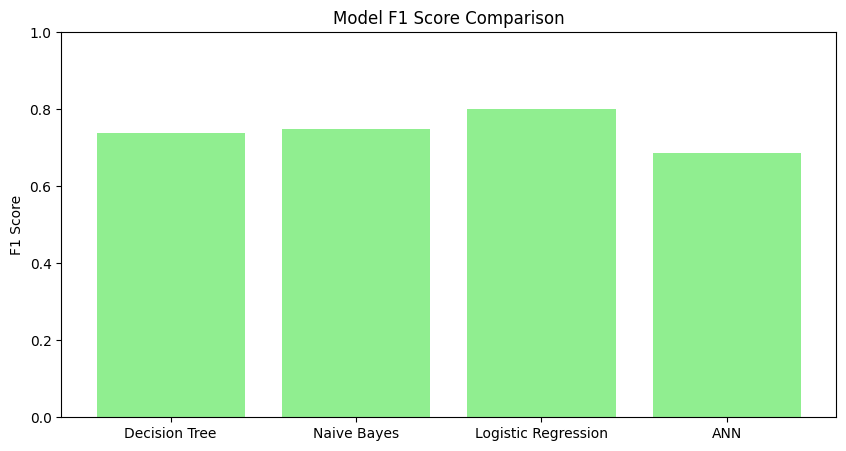

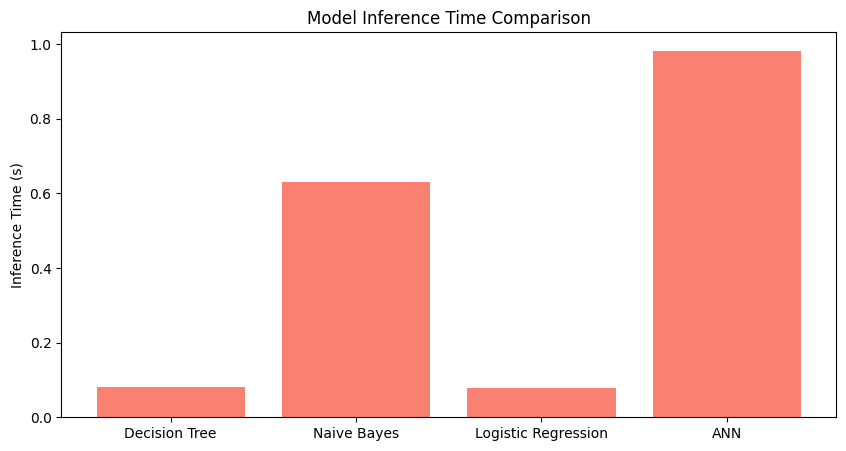

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Bar chart for Accuracy
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

# Bar chart for F1 Scorez
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['F1 Score'], color='lightgreen')
plt.ylabel('F1 Score')
plt.title('Model F1 Score Comparison')
plt.ylim(0, 1)
plt.show()

# Bar chart for Inference Time
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Inference Time (s)'], color='salmon')
plt.ylabel('Inference Time (s)')
plt.title('Model Inference Time Comparison')
plt.show()